In [4]:
import pandas as pd
import joblib

data = pd.read_csv("../data/health_data.csv")

model = joblib.load("../model/health_risk_model.pkl")

X = data[["age", "heart_rate", "temperature", "spo2"]]
y = data["risk"]

print("Data loaded successfully!")
print("Number of rows:", len(data))

Data loaded successfully!
Number of rows: 20


In [6]:
predictions = model.predict(X)

print("Predictions:")
print(predictions)

Predictions:
[0 0 0 0 0 0 1 1 1 1 1 1 1 0 0 0 1 1 1 0]


In [7]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, predictions)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 1.0
Accuracy Percentage: 100.0 %


In [9]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, predictions)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10  0]
 [ 0 10]]


In [10]:
from sklearn.metrics import classification_report

report = classification_report(y, predictions)

print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y, predictions)

plt.title("Health Risk Prediction - Confusion Matrix")
plt.show()

ModuleNotFoundError: No module named 'matplotlib'

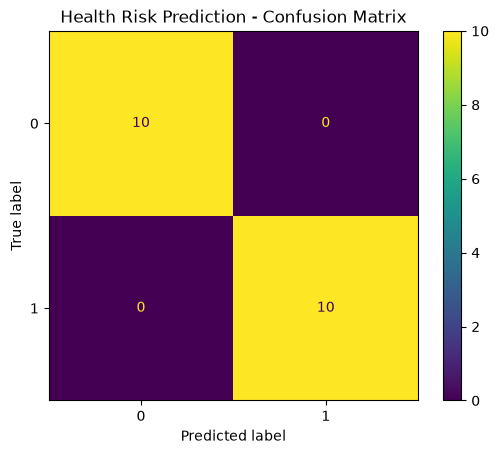

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y, predictions)

plt.title("Health Risk Prediction - Confusion Matrix")
plt.show()

In [13]:
print("Risk distribution:")
print(data["risk"].value_counts())

Risk distribution:
risk
0    10
1    10
Name: count, dtype: int64


In [14]:
from sklearn.model_selection import train_test_split

X = data[["age", "heart_rate", "temperature", "spo2"]]
y = data["risk"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16
Testing samples: 4


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Create a new model
test_model = LogisticRegression()

# Train only on training data
test_model.fit(X_train, y_train)

# Predict unseen test data
test_predictions = test_model.predict(X_test)

# Calculate accuracy
test_accuracy = accuracy_score(y_test, test_predictions)

print("Test Predictions:", test_predictions)
print("Actual Values:", y_test.values)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy Percentage:", test_accuracy * 100, "%")

Test Predictions: [0 0 1 1]
Actual Values: [0 0 1 1]
Test Accuracy: 1.0
Test Accuracy Percentage: 100.0 %


Confusion Matrix:
[[2 0]
 [0 2]]


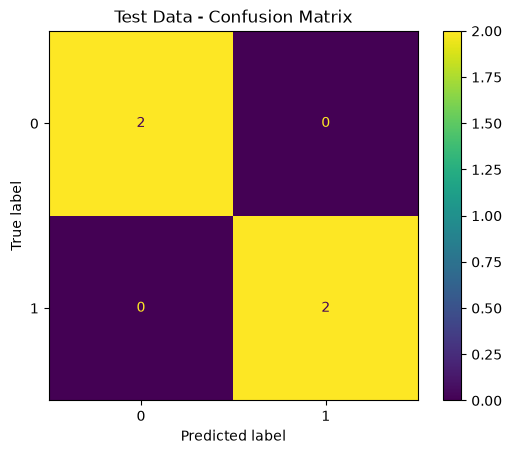

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, test_predictions)

print("Confusion Matrix:")
print(cm)

ConfusionMatrixDisplay.from_predictions(y_test, test_predictions)

plt.title("Test Data - Confusion Matrix")
plt.show()

In [17]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    test_predictions
)

print(report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [19]:
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (4, 4)
y_test shape: (4,)


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Make predictions
predictions = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the new dataset
data = pd.read_csv(
    "../data/Health Monitoring and Fall detection dataset.csv"
)

# 13 features used by the final model
features = [
    "heart_rate",
    "oxygen_level",
    "temperature",
    "acc_x",
    "acc_y",
    "acc_z",
    "gyro_x",
    "gyro_y",
    "gyro_z",
    "acceleration_magnitude",
    "gyro_magnitude",
    "heart_rate_variability",
    "fall_detected"
]

X = data[features]
y = data["health_risk"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_train shape: (489, 13)
X_test shape: (123, 13)
y_test shape: (123,)


In [21]:
import joblib

# Load the final trained model
model = joblib.load("../model/health_risk_model.pkl")

print("Final model loaded successfully!")

Final model loaded successfully!


In [22]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Make predictions
predictions = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, predictions))

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

Accuracy: 1.0
Accuracy Percentage: 100.0 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        38
           1       1.00      1.00      1.00        85

    accuracy                           1.00       123
   macro avg       1.00      1.00      1.00       123
weighted avg       1.00      1.00      1.00       123


Confusion Matrix:
[[38  0]
 [ 0 85]]


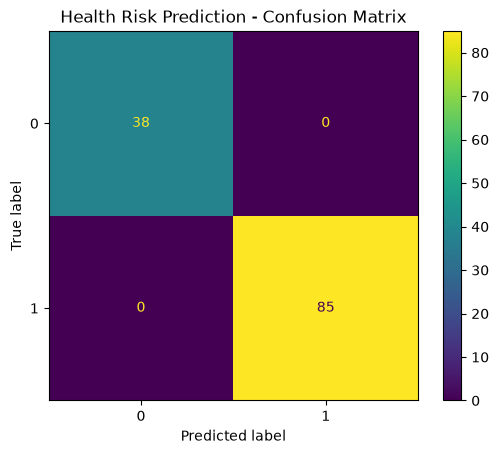

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.title("Health Risk Prediction - Confusion Matrix")
plt.show()